In [7]:
### Exercise 6 
# part 1

# install the packages
import pandas as pd
import matplotlib.pyplot as plt
import os

# download data 
df = pd.read_csv("data/firm_data_ex06.csv")
# need to add the function panda helps to read the csv file


In [8]:
# use OS
#  otherway to download the data using the absolute path 
# it finds the path directly in your computer using the name of the file

PATH_OF_CURRENT_FOLDER = os.getcwd()
P_Research = PATH_OF_CURRENT_FOLDER
data_path = os.path.join(P_Research, "data", "firm_data_ex06.csv")

# read the path
df = pd.read_csv(data_path)
df.head()

,ticker,date,gvkey,comp_name,fiscal_year,fiscal_quarter,assets,net_income,ebitda,revenue,rd_expense,cap_ex_ytd,sector_code
0,AAPL,2005-03-31,1690,APPLE INC,2005,2,10111.0,286.0,438.0,3243.0,120.0,101.0,45
1,AAPL,2005-06-30,1690,APPLE INC,2005,3,10488.0,319.0,472.0,3520.0,145.0,164.0,45
2,AAPL,2005-09-30,1690,APPLE INC,2005,4,11551.0,428.0,468.0,3678.0,147.0,260.0,45
3,AAPL,2005-12-31,1690,APPLE INC,2006,1,14181.0,565.0,802.0,5749.0,182.0,82.0,45
4,AAPL,2006-03-31,1690,APPLE INC,2006,2,13911.0,410.0,579.0,4359.0,176.0,275.0,45


In [11]:
# compact version
base_dir = os.getcwd()
file_path = os.path.join(base_dir, "data", "firm_data_ex06.csv") 
# load the data
df = pd.read_csv(file_path)
df.head()

,ticker,date,gvkey,comp_name,fiscal_year,fiscal_quarter,assets,net_income,ebitda,revenue,rd_expense,cap_ex_ytd,sector_code
0,AAPL,2005-03-31,1690,APPLE INC,2005,2,10111.0,286.0,438.0,3243.0,120.0,101.0,45
1,AAPL,2005-06-30,1690,APPLE INC,2005,3,10488.0,319.0,472.0,3520.0,145.0,164.0,45
2,AAPL,2005-09-30,1690,APPLE INC,2005,4,11551.0,428.0,468.0,3678.0,147.0,260.0,45
3,AAPL,2005-12-31,1690,APPLE INC,2006,1,14181.0,565.0,802.0,5749.0,182.0,82.0,45
4,AAPL,2006-03-31,1690,APPLE INC,2006,2,13911.0,410.0,579.0,4359.0,176.0,275.0,45


In [15]:
## Exo 0.2 
unique_nb = df["ticker"].nunique()
print(f"The number of unique ticker is {unique_nb}")

unique_name = df["ticker"].unique().tolist()
print(f"the name of the unique ticker are: {unique_name}")

The number of unique ticker is 10
the name of the unique ticker are: ['AAPL', 'F', 'GM', 'GOOGL', 'INTC', 'MSFT', 'NVDA', 'TM', 'TSLA', 'VWAGY']


In [ ]:
## Exo 0.3 (my version)
number_obs = df.groupby("ticker").count()
print(number_obs["comp_name"])

ticker
AAPL     84
F        84
GM       84
GOOGL    84
INTC     84
MSFT     84
NVDA     85
TM       84
TSLA     72
VWAGY    82
Name: comp_name, dtype: int64


In [19]:
## Exo 0.3 (correction)
# .value_counts() tells us how many rows exist for each unique entry
print("\nObservations per company:")
print(df['comp_name'].value_counts())


Observations per company:
comp_name
NVIDIA CORP          85
APPLE INC            84
FORD MOTOR CO        84
GENERAL MOTORS CO    84
ALPHABET INC         84
INTEL CORP           84
MICROSOFT CORP       84
TOYOTA MOTOR CORP    84
VOLKSWAGEN AG        82
TESLA INC            72
Name: count, dtype: int64


In [23]:
## Exo 0.4
max_date = df["date"].max()
min_date = df["date"].min()
print(f"earliest date si {min_date} and latest entry is {max_date}")

earliest date si 2005-01-31 and latest entry is 2026-01-31


In [ ]:
## Exo 0.4 (correction)
# Note: Because the dates are currently loaded as strings, pandas finds the 
# min/max by sorting them alphabetically. This only works correctly if 
# the strings are perfectly formatted as YYYY-MM-DD!

print(f"\nData starts on: {df['date'].min()}")
print(f"Data ends on:   {df['date'].max()}")

Exercise 1: Identifying and Handling Missing Data
In the lecture, we discussed how the 2025 federal shutdown caused a gap in official unemployment statistics. Corporate financial data is often much messier and contains structural missing values (NaNs) because different industries/firms follow different reporting standards. This exercise focuses on identifying these gaps and applying appropriate strategies to handle them.

Part A: Identifying Gaps
Before fixing data, you must understand where it is broken. We start by quantifying the missing values in our dataset.

Your Tasks

Overview: Use the .info() method to get a high-level summary of the dataset. Which columns appear to have the most missing values?

Quantification: Calculate the exact number of NaN entries for every variable.

Identify Affected Firms: Pinpoint exactly which companies have missing data for a specific variable (e.g., assets). Create a subset of the data containing only the rows where that variable is NaN, then extract a list of the unique company names.

In [24]:
# Exo 1.1
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 827 entries, 0 to 826
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ticker          827 non-null    str    
 1   date            827 non-null    str    
 2   gvkey           827 non-null    int64  
 3   comp_name       827 non-null    str    
 4   fiscal_year     827 non-null    int64  
 5   fiscal_quarter  827 non-null    int64  
 6   assets          819 non-null    float64
 7   net_income      824 non-null    float64
 8   ebitda          807 non-null    float64
 9   revenue         824 non-null    float64
 10  rd_expense      668 non-null    float64
 11  cap_ex_ytd      813 non-null    float64
 12  sector_code     827 non-null    int64  
dtypes: float64(6), int64(4), str(3)
memory usage: 84.1 KB


In [ ]:
# Exo 1.2
df.isna().sum()

ticker              0
date                0
gvkey               0
comp_name           0
fiscal_year         0
fiscal_quarter      0
assets              8
net_income          3
ebitda             20
revenue             3
rd_expense        159
cap_ex_ytd         14
sector_code         0
dtype: int64

In [26]:
## Exo 1.2 (correction)
# .isna() returns True for missing values; .sum() counts those Trues
missing_counts = df.isna().sum()
missing_counts

ticker              0
date                0
gvkey               0
comp_name           0
fiscal_year         0
fiscal_quarter      0
assets              8
net_income          3
ebitda             20
revenue             3
rd_expense        159
cap_ex_ytd         14
sector_code         0
dtype: int64

In [27]:
# Exo 1.3
def findNAs(df, var_name):
    missing_rows = df[df[var_name].isna()]                  # return true or false if there is an na to keep it in the dataset
    firms_na = missing_rows["comp_name"].unique().tolist()  # sort all the data with the company name instead of variable to keep the company name with na
    print(f"Variable: {var_name} - {len(firms_na)} firms with missing values:")
    print(firms_na)

def findAllNAs(df):
    for col in df.columns[df.isna().any()]:
        findNAs(df, col)

findAllNAs(df)


Variable: assets - 3 firms with missing values:
['GENERAL MOTORS CO', 'TESLA INC', 'VOLKSWAGEN AG']
Variable: net_income - 1 firms with missing values:
['TESLA INC']
Variable: ebitda - 4 firms with missing values:
['GENERAL MOTORS CO', 'TOYOTA MOTOR CORP', 'TESLA INC', 'VOLKSWAGEN AG']
Variable: revenue - 1 firms with missing values:
['TESLA INC']
Variable: rd_expense - 5 firms with missing values:
['FORD MOTOR CO', 'GENERAL MOTORS CO', 'TOYOTA MOTOR CORP', 'TESLA INC', 'VOLKSWAGEN AG']
Variable: cap_ex_ytd - 4 firms with missing values:
['GENERAL MOTORS CO', 'TOYOTA MOTOR CORP', 'TESLA INC', 'VOLKSWAGEN AG']


In [ ]:
# Exo 1.3 (correction - simpler version)
var_name = 'assets'                     # Change variable here to
missing_rows = df[df[var_name].isna()]
firms_nan = missing_rows['comp_name'].unique().tolist()
print(firms_nan)

Part B: Strategies for Handling Missing Data

Now that we know where the gaps are we can think about strategies to handle them. There are three strategies we consider:

Dropping: Removing incomplete rows.
Filling: Replacing NaN with a constant (like 0 for R&D).

Interpolation: Estimating values by “drawing a line” between known points.
Your Tasks

The Aggressive Approach: Create a new DataFrame called df_dropped by dropping all rows where there are ANY missing values. How many observations did you lose? How can you drop observations in a less aggressive way?

In [32]:
df_dropped = df.dropna()
rows_lost = len(df) - len(df_dropped)
print(f"original rows: {len(df)}")
print(f"after removing na: {len(df_dropped)}")
print(f"rows lost: {rows_lost}")

# df_dropped_subset = df.dropna(subset=['assets']) less aggressive approach only drop the row of a certain subset

original rows: 827
after removing na: 657
rows lost: 170


In [34]:
df["rd_filled"] =df["rd_expense"].fillna(0)

df[df["rd_expense"].isna()][["date", "rd_expense", "rd_filled"]].head()

,date,rd_expense,rd_filled
84,2005-03-31,NaN,0.0
85,2005-06-30,NaN,0.0
86,2005-09-30,NaN,0.0
88,2006-03-31,NaN,0.0
89,2006-06-30,NaN,0.0


In [42]:
df['assets_interp'] = df['assets'].interpolate(method='linear')
df[df["ticker"] == "TSLA"][["date", "comp_name", "assets", "assets_interp"]].head(10)

,date,comp_name,assets,assets_interp
673,2008-03-31,TESLA INC,NaN,489582.92475
674,2008-06-30,TESLA INC,NaN,326405.84950
675,2008-09-30,TESLA INC,NaN,163228.77425
676,2008-12-31,TESLA INC,51.699,51.69900
677,2009-03-31,TESLA INC,NaN,71.38025
678,2009-06-30,TESLA INC,NaN,91.06150
679,2009-09-30,TESLA INC,NaN,110.74275
680,2009-12-31,TESLA INC,130.424,130.42400
681,2010-03-31,TESLA INC,145.320,145.32000
682,2010-06-30,TESLA INC,147.974,147.97400


The first time Tesla reports assets is 2008 Q4, the interpolated values come from another company that appeared before tesla in the data.

A cautionary tale: Applying interpolate() to the dataframe like this was a solution suggested by AI, it runs without an error, but it’s not correct. AI is very helpful for programming, but it is still crucial to have a good understanding of the code and to come up with ways to check whether it’s actually correct. Just because something runs without an error doesn’t mean it’s doing what was intended.

In [44]:
df["assets_interp"] = (df.groupby("ticker")["assets"].transform(lambda x:x.interpolate(method = "linear")))

df[df["ticker"] == "TSLA"][["date", "comp_name", "assets", "assets_interp"]].head(10)

,date,comp_name,assets,assets_interp
673,2008-03-31,TESLA INC,NaN,NaN
674,2008-06-30,TESLA INC,NaN,NaN
675,2008-09-30,TESLA INC,NaN,NaN
676,2008-12-31,TESLA INC,51.699,51.69900
677,2009-03-31,TESLA INC,NaN,71.38025
678,2009-06-30,TESLA INC,NaN,91.06150
679,2009-09-30,TESLA INC,NaN,110.74275
680,2009-12-31,TESLA INC,130.424,130.42400
681,2010-03-31,TESLA INC,145.320,145.32000
682,2010-06-30,TESLA INC,147.974,147.97400


lambda x: x.interpolate(method='linear')

def my_function(x):
    return x.interpolate(method='linear')
```

Just shorter — no need to give it a name since it's only used once.

**The `x` represents one group at a time.** So when the loop runs:
- First iteration: `x` = all AAPL rows
- Second iteration: `x` = all TSLA rows
- Third iteration: `x` = all GOOGL rows

In [45]:
# First step: Sort dataframe by firms and date!
df = df.sort_values(['ticker', 'date'])

# Then you can interpolate
df['assets_interp'] = df.groupby('ticker')['assets'].transform(lambda x: x.interpolate(method='linear'))

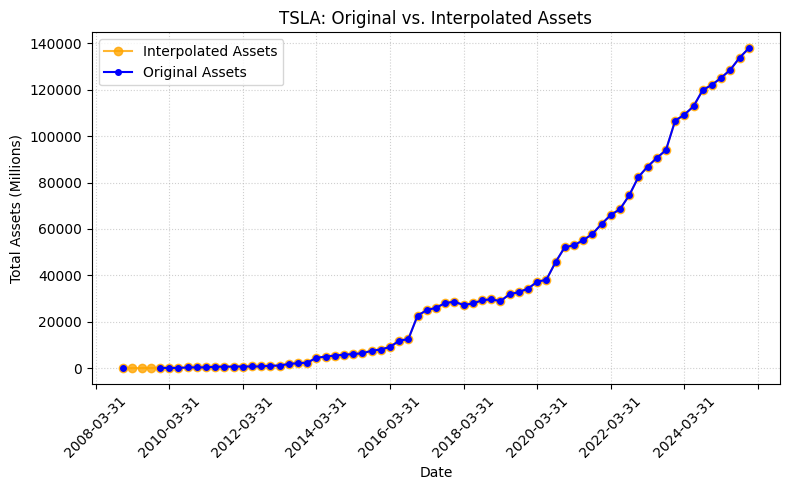

In [48]:
def plot_firm_assets(ticker_name):
    """
    Plots original vs. interpolated assets for a specific ticker.
    """
    # 1. Filter for the specific firm
    firm_data = df[df['ticker'] == ticker_name]
    
    # 2. Create the plot
    plt.figure(figsize=(8, 5))
    
    # Plot interpolated data (continuous line)
    plt.plot(firm_data['date'], firm_data['assets_interp'], 
             label='Interpolated Assets', color='orange', linestyle='-', marker='o', alpha=0.8)
    
    # Plot original data (points with gaps)
    plt.plot(firm_data['date'], firm_data['assets'], 
             label='Original Assets', color='blue', marker='o', markersize=4)
    
    # 3. Formatting
    plt.title(f"{ticker_name}: Original vs. Interpolated Assets")
    plt.xlabel("Date")
    plt.ylabel("Total Assets (Millions)")
    plt.legend()
    plt.xticks(rotation=45)
    plt.gca().xaxis.set_major_locator(plt.MaxNLocator(10))
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()


plot_firm_assets("TSLA")

Teslas assets show a relatively smooth trajectory, so linear interpolation seems reasonable. The growth trajectory could be exponential, which we could account for by using a different method in interpolate(). But the orange interpolated segments are short, meaning we are only “guessing” for a few quarters at a time. The closer the known data points are to each other, the more accurate linear interpolation tends to be.

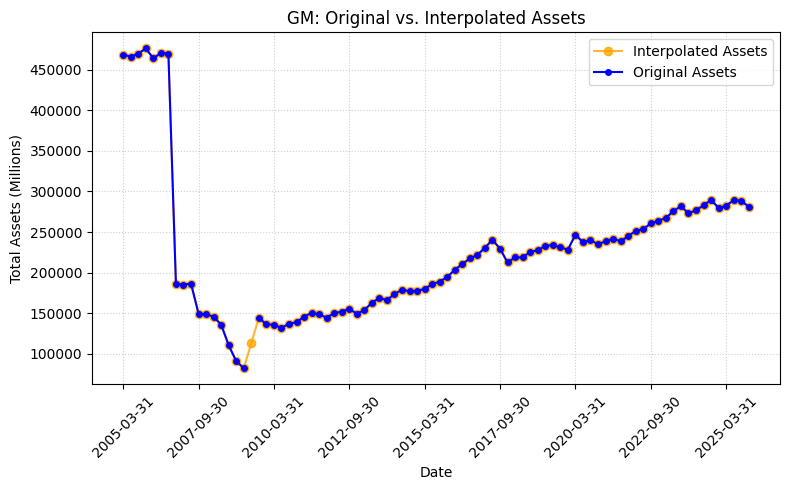

In [49]:
plot_firm_assets('GM')

In GM’s case linear interpolation may not be reasonable. The “missing/odd” asset value in 2009 Q2 lines up with its bankruptcy filing (June 1, 2009) and the rapid sale of most operating assets into a newly created “New GM” (completed July 10, 2009). In other words, this isn’t a normal, smooth evolution of the same balance sheet—it’s a break in the reporting entity and accounting perimeter (assets and liabilities were split between “Old GM”/liquidation and the reorganized company). Because linear interpolation assumes the underlying process is continuous and comparable quarter to quarter, it’s not economically meaningful here: the “true” path wasn’t a gradual transition, it was a discrete restructuring event.

In [51]:
## Exo 2 

# Exo 2.1
# 1. Convert to datetime
print(df['date'].dtype)
df['date'] = pd.to_datetime(df['date']) 
print(f"New Data Type: {df['date'].dtype}") 
df["date"]

datetime64[us]
New Data Type: datetime64[us]


0     2005-03-31
1     2005-06-30
2     2005-09-30
3     2005-12-31
4     2006-03-31
         ...    
822   2024-06-30
823   2024-09-30
824   2024-12-31
825   2025-03-31
826   2025-06-30
Name: date, Length: 827, dtype: datetime64[us]

In [ ]:
df = df.set_index("date")
print(f"Index Type: {type(df.index)}")
df.sort_index

# Display the first 10 rows of the dataframe sorted by its index
# df.sort_index().head(10)

Index Type: <class 'pandas.DatetimeIndex'>


<bound method DataFrame.sort_index of            ticker   gvkey      comp_name  fiscal_year  fiscal_quarter  \
date                                                                    
2005-03-31   AAPL    1690      APPLE INC         2005               2   
2005-06-30   AAPL    1690      APPLE INC         2005               3   
2005-09-30   AAPL    1690      APPLE INC         2005               4   
2005-12-31   AAPL    1690      APPLE INC         2006               1   
2006-03-31   AAPL    1690      APPLE INC         2006               2   
...           ...     ...            ...          ...             ...   
2024-06-30  VWAGY  100737  VOLKSWAGEN AG         2024               2   
2024-09-30  VWAGY  100737  VOLKSWAGEN AG         2024               3   
2024-12-31  VWAGY  100737  VOLKSWAGEN AG         2024               4   
2025-03-31  VWAGY  100737  VOLKSWAGEN AG         2025               1   
2025-06-30  VWAGY  100737  VOLKSWAGEN AG         2025               2   

            

In [53]:
# First sort the index 
# Note: DatetimeIndex allows us to slice by year strings directly
print(f"Is the index sorted? {df.index.is_monotonic_increasing}")
df = df.sort_index()
print(f"Is the index sorted? {df.index.is_monotonic_increasing}")

# Slice the Great Financial Crisis window
# Note: DatetimeIndex allows us to slice by year strings directly
df_gfc = df.loc["2008":"2010"] 

df_gfc.head()

Is the index sorted? False
Is the index sorted? True


,ticker,gvkey,comp_name,fiscal_year,fiscal_quarter,assets,net_income,ebitda,revenue,rd_expense,cap_ex_ytd,sector_code,rd_filled,assets_interp
date,,,,,,,,,,,,,,
2008-01-31,NVDA,117768,NVIDIA CORP,2007,4,3747.671,256.993,303.435,1202.730,195.835,187.745,45,195.835,3747.671
2008-03-31,GM,5073,GENERAL MOTORS CO,2008,1,145741.000,-3282.000,2695.000,42383.000,NaN,1945.000,25,0.000,145741.000
2008-03-31,TSLA,184996,TESLA INC,2008,1,NaN,NaN,NaN,NaN,NaN,NaN,25,0.000,NaN
2008-03-31,VWAGY,100737,VOLKSWAGEN AG,2008,1,235970.231,1468.285,4585.030,42694.047,1809.673,2492.449,25,1809.673,235970.231
2008-03-31,GOOGL,160329,ALPHABET INC,2008,1,27604.982,1307.086,1881.799,5186.043,673.069,841.597,50,673.069,27604.982


In [ ]:
## Exo 3

# 1. Total Annual Revenue
# We use 'YE' for Year-End to resample
# aggregation method .sum()
annual_rev = df.groupby('ticker')['revenue'].resample('YE').sum()
annual_rev.head()


ticker  date      
AAPL    2005-12-31    16190.0
        2006-12-31    20681.0
        2007-12-31    26499.0
        2008-12-31    34751.0
        2009-12-31    46708.0
Name: revenue, dtype: float64

In [59]:
# Define which math to apply to which column (annual data for each variable)
df_annual = df.groupby('ticker').resample('YE').agg({
    'revenue': 'sum',
    'net_income': 'sum',
    'assets': 'last'
})
df_annual.head()

revenue  net_income   assets
ticker date                                    
AAPL   2005-12-31  16190.0      1598.0  14181.0
       2006-12-31  20681.0      2428.0  19461.0
       2007-12-31  26499.0      4073.0  30039.0
       2008-12-31  34751.0      5508.0  42787.0
       2009-12-31  46708.0      9358.0  53926.0

In [60]:
# Subtask A: Selection
# On a MultiIndex (Ticker, Date), .loc picks the first level by default
aapl_annual = df_annual.loc['AAPL']
print("Apple Annual Data:")
aapl_annual.head()

Apple Annual Data:


,revenue,net_income,assets
date,,,
2005-12-31,16190.0,1598.0,14181.0
2006-12-31,20681.0,2428.0,19461.0
2007-12-31,26499.0,4073.0,30039.0
2008-12-31,34751.0,5508.0,42787.0
2009-12-31,46708.0,9358.0,53926.0


In [61]:
# Subtask B: Full Reset
# This turns everything into a 'flat' table, ideal for plotting or exporting to CSV
df_flat = df_annual.reset_index()
df_flat.head()

,ticker,date,revenue,net_income,assets
0,AAPL,2005-12-31,16190.0,1598.0,14181.0
1,AAPL,2006-12-31,20681.0,2428.0,19461.0
2,AAPL,2007-12-31,26499.0,4073.0,30039.0
3,AAPL,2008-12-31,34751.0,5508.0,42787.0
4,AAPL,2009-12-31,46708.0,9358.0,53926.0


In [62]:
# Subtask C: Partial Reset
# This moves the 'ticker' to a column but keeps the 'date' as the index
df_partial_reset = df_annual.reset_index(level='ticker')

df_partial_reset.head()

,ticker,revenue,net_income,assets
date,,,,
2005-12-31,AAPL,16190.0,1598.0,14181.0
2006-12-31,AAPL,20681.0,2428.0,19461.0
2007-12-31,AAPL,26499.0,4073.0,30039.0
2008-12-31,AAPL,34751.0,5508.0,42787.0
2009-12-31,AAPL,46708.0,9358.0,53926.0


In [63]:
## Exo 4

# Exo 4.1
# To calculate YoY growth correctly in a panel, we must group by ticker.
# This prevents 'leaking' data between different firms.
# A lag of 4 is used for quarterly data to compare the same quarter across years.
df['rev_growth'] = df.groupby('ticker')['revenue'].pct_change(4) * 100

# Inspecting the result
df[df['ticker'] == 'NVDA'].head()

,ticker,gvkey,comp_name,fiscal_year,fiscal_quarter,assets,net_income,ebitda,revenue,rd_expense,cap_ex_ytd,sector_code,rd_filled,assets_interp,rev_growth
date,,,,,,,,,,,,,,,
2005-01-31,NVDA,117768,NVIDIA CORP,2004,4,1628.536,48.009,88.241,566.476,84.054,67.261,45,84.054,1628.536,NaN
2005-04-30,NVDA,117768,NVIDIA CORP,2005,1,1635.094,65.522,103.706,583.846,87.835,13.504,45,87.835,1635.094,NaN
2005-07-31,NVDA,117768,NVIDIA CORP,2005,2,1728.218,73.833,102.363,574.812,87.113,42.689,45,87.113,1728.218,NaN
2005-10-31,NVDA,117768,NVIDIA CORP,2005,3,1805.508,64.447,108.252,583.415,88.829,56.155,45,88.829,1805.508,NaN
2006-01-31,NVDA,117768,NVIDIA CORP,2005,4,1954.687,97.374,134.478,633.614,93.346,79.600,45,93.346,1954.687,11.85187


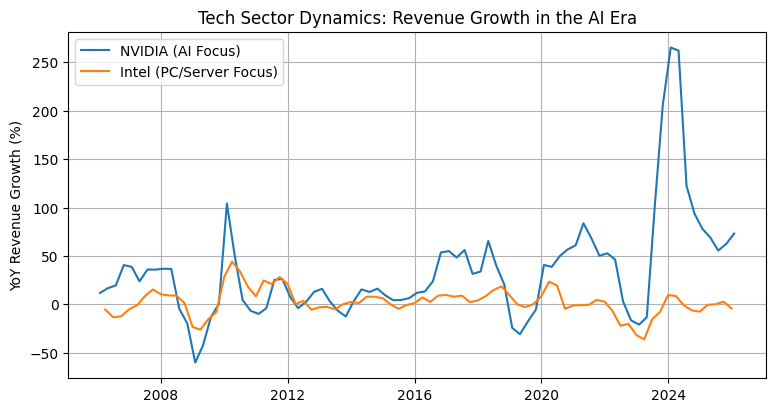

In [64]:
# 1. Filter the data
nvda = df[df['ticker'] == 'NVDA']
intc = df[df['ticker'] == 'INTC']

# 2. Setup the figure
plt.figure(figsize=(9, 4.5))

# 3. Plot the growth rates
plt.plot(nvda.index, nvda['rev_growth'], label='NVIDIA (AI Focus)')
plt.plot(intc.index, intc['rev_growth'], label='Intel (PC/Server Focus)')


# 5. Professional Styling
plt.title("Tech Sector Dynamics: Revenue Growth in the AI Era")
plt.ylabel("YoY Revenue Growth (%)")
plt.legend()
plt.grid()
plt.show()

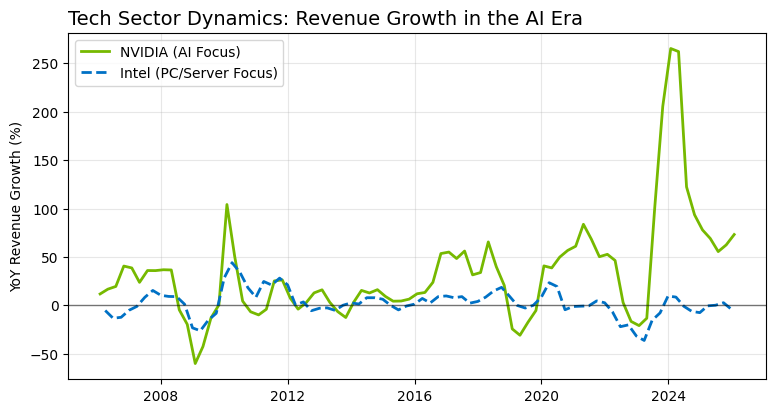

In [65]:
nvda = df[df['ticker'] == 'NVDA']
intc = df[df['ticker'] == 'INTC']


plt.figure(figsize=(9, 4.5))

# New: change color, linestyle, linewidth
plt.plot(nvda.index, nvda['rev_growth'], label='NVIDIA (AI Focus)', color='#76b900', lw=2)
plt.plot(intc.index, intc['rev_growth'], label='Intel (PC/Server Focus)', color='#0071c5', lw=2, linestyle='--')

# New: change location and fontsiize of title
plt.title("Tech Sector Dynamics: Revenue Growth in the AI Era", loc='left', fontsize=14) 
plt.ylabel("YoY Revenue Growth (%)")
plt.legend()

# New: Add baseline
plt.axhline(0, color='black', lw=1, alpha=0.5)

# New: Make grid more subtle
plt.grid(alpha=0.3)

plt.show()

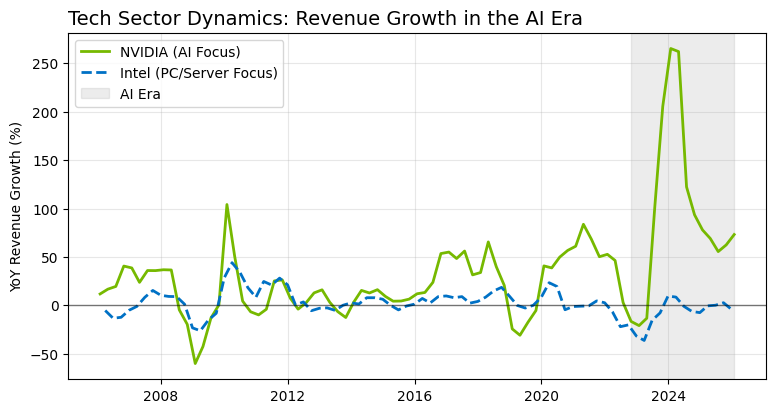

In [66]:
nvda = df[df['ticker'] == 'NVDA']
intc = df[df['ticker'] == 'INTC']

plt.figure(figsize=(9, 4.5))

plt.plot(nvda.index, nvda['rev_growth'], label='NVIDIA (AI Focus)', color='#76b900', lw=2)
plt.plot(intc.index, intc['rev_growth'], label='Intel (PC/Server Focus)', color='#0071c5', lw=2, linestyle='--')

# New: Add context AI Era
ai_start = pd.to_datetime('2022-11-01')
plt.axvspan(ai_start, df.index.max(), color='grey', alpha=0.15, label='AI Era')


plt.title("Tech Sector Dynamics: Revenue Growth in the AI Era", loc='left', fontsize=14)
plt.ylabel("YoY Revenue Growth (%)")
plt.legend()

plt.axhline(0, color='black', lw=1, alpha=0.5)
plt.grid(alpha=0.3)

plt.show()

In [67]:
## Exo 5

def compare_growth(df, ticker_1, ticker_2):
    # Filter the data
    firm_a = df[df['ticker'] == ticker_1]
    firm_b = df[df['ticker'] == ticker_2]

    # Setup the figure
    plt.figure(figsize=(9, 4.5))

    # Plot lines with the styling from Ex 4
    plt.plot(firm_a.index, firm_a['rev_growth'], label=f'{ticker_1}', color='#76b900', lw=2)
    plt.plot(firm_b.index, firm_b['rev_growth'], label=f'{ticker_2}', color='#0071c5', lw=2, linestyle='--')

    # Add AI Era Shading (using pd.to_datetime for axis compatibility)
    ai_start = pd.to_datetime('2022-11-01')
    plt.axvspan(ai_start, df.index.max(), color='gray', alpha=0.15, label='AI Era')

    # Professional Styling
    plt.axhline(0, color='black', lw=1, alpha=0.5)
    plt.grid(axis='y', alpha=0.3)
    plt.title(f"Tech Sector Dynamics: {ticker_1} vs {ticker_2}", loc='left', fontsize=14)
    plt.ylabel("YoY Revenue Growth (%)")

    plt.legend()
    plt.show()

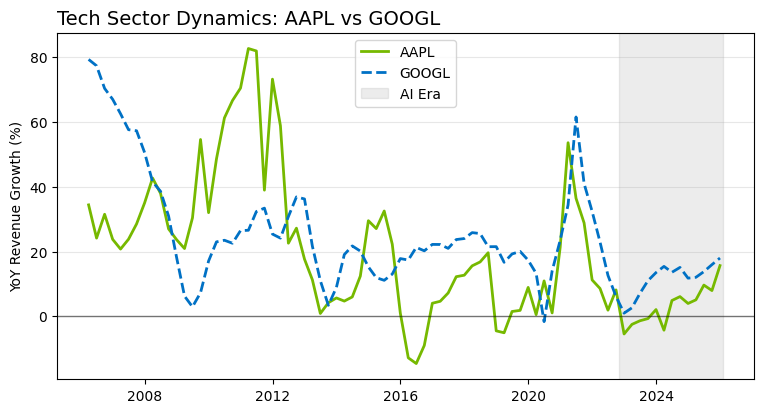

In [68]:
# Test the function, use different tickers e.g. apple and google
compare_growth(df, 'AAPL', 'GOOGL')

(i) Feature Expansion

Metric Selection: Add an argument to choose between net_income, revenue, or profit_margins when comparing the companies
Flexible Shading: Add a boolean argument (show_ai_era=True) to toggle the shading on or off.
Benchmarking: Add a line representing the industry average to see if a firm is “beating the market”.
Company Name Mapping: Use a dictionary (e.g., names = {'NVDA': 'NVIDIA Corp', ...}) so the legend / titledisplays the full name instead of the ticker symbol.
…
(ii) Robustness

Ticker Verification: Use an if statement to check if the input tickers exist in your dataset. If it doesn’t print a helpful message and exit.
Frequency Verification: Ensure the data is actually quarterly. If there is a “hole” in the time series (e.g., a missing year of filings), pct_change(4) will return incorrect results.
Financial data often contains “fat tails” or one-time accounting adjustments (like a massive legal settlement). You could add a check that warns the user if a growth rate exceeds a certain threshold (e.g., >500%), but plots the figure anyway
Overlap Check: Verify that the two firms have overlapping date ranges so the comparison is actually possible on a single timeline.
…
Also visually the figure could be improved, for example the legend moves around depending on the data, we could fix the location using loc= but have to consider an option that works irrespective of the data.